# XGBoost + Optuna - Train and Tune a Classifier On The Titanic Dataset

XGBoost is a popular tree-based classification algorithm frequently used with tabular data. It is extremely robust and can handle a wide variety of scenarios.

Optuna is a popular hyperparameter tuner which is framework agnostic - i.e. can be used with almost anything.

In this notebook, I combine XGBoost with Optuna to train and tune a binary classifier on the Titanic dataset.

I will first train a classifier with no tuning to obtain a baseline to compare against and then, use Optuna to automatically tune the classifier.

# Basic configuration

The followinig section defines some basic configuration parameters that will be used throughtout the notebook.

In [1]:
DATA_DIR = "../input/titanic"
N_JOBS = 2

# These parameters are used to give Optuna a head start
MAX_DEPTH = 5
ALPHA = 0.3
LR = 0.3
N_ESTIMATORS = 100

FOLDS = 5
EARLY_STOPPING_ROUNDS = 15
SHUFFLE = True
TUNED_MODELS_DIR = "./models-tuned"
NO_TUNED_MODELS_DIR = "./models-no-tuning"

# Imports

In [2]:
from __future__ import annotations

import functools
import gc
import glob
import os
from typing import Any, Dict, Tuple, List

import matplotlib.pyplot as plt
import optuna
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn import metrics, model_selection, preprocessing, impute
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

In [3]:
dirs = ["roc", "feature_importance", "loss_curves"]

if not os.path.exists(TUNED_MODELS_DIR):
    os.mkdir(TUNED_MODELS_DIR)
    for d in dirs:
        path = os.path.join(TUNED_MODELS_DIR, d)
        os.mkdir(path)
    
if not os.path.exists(NO_TUNED_MODELS_DIR):
    os.mkdir(NO_TUNED_MODELS_DIR)
    for d in dirs:
        path = os.path.join(NO_TUNED_MODELS_DIR, d)
        os.mkdir(path)

# Custom Types For Type Hints

In [4]:
EncoderDict = Dict[str, preprocessing.LabelEncoder]
InitDict = Dict[str, Any]

# Data functions

The `encode()` function is used to encode the various categorical variables present in the dataset. It takes in a NumPy array of values and an optional `LabelEncoder` instance. An encoder is created by the function if one is not provided already. It returns the encoded NumPy array.

In [5]:
def encode(
    values: np.ndarray, *, encoder: preprocessing.LabelEncoder = None
) -> np.ndarray:
    if encoder is None:
        encoder = preprocessing.LabelEncoder()
        encoder.fit(values)

    return encoder.fit_transform(values)

# Training functions

The `get_model_params()` function is used to obtain the initialization parameters for `xgb.XGBClassifier`. This will make using the hyperparameters suggested by Optuna easier. The function takes a dictionary of parameters and then selects those that are relevant for the model.

In [6]:
def get_model_params(params: InitDict) -> InitDict:
    return {
        "max_depth": params.get("max_depth", 6),
        "n_estimators": params.get("n_estimators", 100),
        "objective": params.get("objective", "binary:logistic"),
        "alpha": params.get("alpha", 0.0),
        "lambda": params.get("lambda", 1),
        "learning_rate": params.get("lr", 0.3),
        "colsample_bytree": params.get("colsample_bytree", 1.0),
        "colsample_bylevel": params.get("colsample_bylevel", 1.0),
        "min_child_weight": params.get("min_child_weight", 1),
        "subsample": params.get("subsample", 1.0),
        "sampling_method": params.get("sampling_method", "uniform"),
        "scale_pos_weight": params.get("scale_pos_weight", 1.0),
        "tree_method": "gpu_hist",
        "use_label_encoder": False,
        "n_jobs": N_JOBS,
        "predictor": "gpu_predictor",
        "eval_metric": "logloss",
        "max_bin": 1024,
    }

The `Engine` class is used to encapsulate model training. It has methods to save the model, calculate the ROC score and training the model.

In [7]:
class Engine:
    def __init__(self, model: xgb.XGBClassifier) -> None:
        self.model = model
        
    @staticmethod
    def roc(true: np.ndarray, preds: np.ndarray) -> float:
        return metrics.roc_auc_score(true, preds)
    
    def save_roc_curve(self, filepath: str, X_val: np.ndarray, y_val: np.ndarray) -> None:
        preds = self.model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = metrics.roc_curve(y_val, preds)
        roc = self.roc(y_val, preds)

        plt.figure()
        plt.plot(fpr, tpr, color="darkorange", label=f"ROC curve (roc={roc:.4f})")
        plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
        plt.xlim([-0.02, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curve")
        plt.legend(loc="lower right")
        
        path = os.path.join(MODEL_DIR, "roc", filepath)
        plt.savefig(path)
        plt.clf()
        
    def save_feature_importance_plot(self, filepath: str) -> None:
        xgb.plot_importance(self.model)
        path = os.path.join(MODEL_DIR, "feature_importance", filepath)
        plt.savefig(path)
        plt.clf()
        
    def save_loss_curve(self, filepath: str) -> None:
        eval_results = self.model.evals_result()

        train_loss = eval_results["validation_0"]["logloss"]
        val_loss = eval_results["validation_1"]["logloss"]
        
        plt.figure()
        plt.plot(train_loss, label="Training")
        plt.plot(val_loss, label="Validation")
        plt.axvline(self.model.best_iteration, color="black", linestyle="--", label="Best iteration")
        
        plt.xlabel("Round")
        plt.ylabel("Loss")
        plt.title("Loss Curve")
        plt.legend()
        
        path = os.path.join(MODEL_DIR, "loss_curves", filepath)
        plt.savefig(path)
        plt.clf()
        
    def save_model(self, filepath: str) -> None:
        path = os.path.join(MODEL_DIR, filepath)
        self.model.save_model(path)

    def train(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        early_stopping_rounds: int = None,
        callbacks: list = None,
    ) -> Tuple[float, float, np.float32, np.float32]:
        model = self.model

        model.fit(
            X=X_train,
            y=y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_metric="logloss",
            verbose=False,
            early_stopping_rounds=early_stopping_rounds,
            callbacks=callbacks,
        )

        eval_results = model.evals_result()

        train_loss = np.mean(eval_results["validation_0"]["logloss"], dtype=np.float32)
        val_loss = np.mean(eval_results["validation_1"]["logloss"], dtype=np.float32)
        
        preds = model.predict(X_val)
        accuracy = metrics.accuracy_score(y_val, preds)

        preds = model.predict_proba(X_val)[:, 1]
        roc = self.roc(y_val, preds)
        
        return accuracy, roc, train_loss, val_loss

The `train()` function runs the main training loop. It takes the features and the labels and then trains a classifier in a CV loop. Optionally, it also saves the model. In the end, it returns the average validation log loss of all the folds.

In [8]:
def train(
    X: np.ndarray, y: np.ndarray, params: InitDict, save_model: bool = False
) -> Tuple[np.float32, np.float32]:
    cv = model_selection.StratifiedKFold(n_splits=FOLDS, random_state=42)

    folds = cv.split(X, y)

    scores, losses, accuracies = [], [], []
    
    callbacks = params.get("callbacks")
    early_stopping_rounds = params.get("early_stopping_rounds")

    with tqdm(folds, total=FOLDS) as p_folds:
        for fold, (train_idx, val_idx) in enumerate(p_folds):
            p_folds.set_description(f"Fold {fold + 1}")

            X_train, y_train = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]

            classifier = xgb.XGBClassifier(**get_model_params(params), random_state=42)

            engine = Engine(model=classifier)

            accuracy, roc, train_loss, val_loss = engine.train(
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                early_stopping_rounds=early_stopping_rounds,
                callbacks=callbacks,
            )
            gc.collect()

            if save_model is True:
                key = fold + 1
                engine.save_model(f"model-{key}.json")
                engine.save_roc_curve(f"model-{key}.png", X_val, y_val)
                engine.save_feature_importance_plot(f"model-{key}.png")
                engine.save_loss_curve(f"model-{key}.png")

            p_folds.set_postfix(roc=roc, loss=train_loss, val_loss=val_loss, acc=accuracy)

            scores.append(roc)
            losses.append(val_loss)
            accuracies.append(accuracy)

    return np.mean(scores), np.mean(losses), accuracies

# Plotting Functions

The `plot()` function plots the plots in the given directory. This is used to view the feature importances, ROC curves and loss curves.

In [9]:
def plot(directory: str) -> None:
    gridspec_kw = {"wspace": 0.1, "hspace": 0.1}
    fig, axs = plt.subplots(3, 2, figsize=(20, 20), gridspec_kw=gridspec_kw)
    axs = axs.flatten()
    path = os.path.join(MODEL_DIR, directory, "*.png")

    for img_path, ax in zip(sorted(glob.glob(path)), axs):
        basename = os.path.basename(img_path)
        filename, _ = os.path.splitext(basename)
        img = plt.imread(img_path)
        ax.set_axis_off()
        ax.imshow(img)
        ax.set_title(filename)
        
    for ax in axs.flat:
        if not ax.has_data():
            fig.delaxes(ax)

# Optuna Objective

Optuna requires an objective function which returns some numerical value that Optuna will aim to minimize/maximize. The first argument of this function is conventionally called `trial` and is a `optuna.trial.Trial` object representing the current trial. Thus, `objective()` is a wrapper around `train()`.

In [10]:
def objective(trial: optuna.trial.Trial, X: np.ndarray, y: np.ndarray, pruner: bool = False) -> np.float32:
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 11),
        "n_estimators": trial.suggest_int("n_estimators", 5, 300),
        "alpha": trial.suggest_uniform("alpha", 0.0, 5.0),
        "lambda": trial.suggest_float("lambda", 1.0, 5.0, log=True),
        "lr": trial.suggest_float("lr", 0.03, 0.8, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.2, 1.0),
        "min_child_weight": trial.suggest_uniform("min_child_weight", 1, 50),
        "sampling_method": trial.suggest_categorical("sampling_method", ["uniform", "gradient_based"]),
        "scale_pos_weight": trial.suggest_uniform("scale_pos_weight", 1, 5),
        "early_stopping_rounds": trial.suggest_int("early_stopping_rounds", 5, 20, step=5),
    }
    
    if pruner is True:
        params["callbacks"] = [optuna.integration.XGBoostPruningCallback(trial, "validation_1-logloss")]

    roc, loss, _ = train(X, y, params)
    return loss

# Feature Engineering

This section has some basic feature engineering.

# Combine Train and Test

In [11]:
# Read in the two datasets
tr_df = pd.read_csv("../input/titanic/train.csv", index_col="PassengerId")
te_df = pd.read_csv("../input/titanic/test.csv", index_col="PassengerId")

# Take out labels from training data
survived = tr_df["Survived"].copy()
tr_df = tr_df.drop("Survived", axis=1)

# Store indices
tr_index = tr_df.index
te_index = te_df.index

df = pd.concat([tr_df, te_df])
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Using Presence of Missing Values As A Feature

A new feature called `missing_<feature>` is added which is `True` if the row had missing values for that particular feature before imputing them.

In [12]:
df["missing_Age"] = df["Age"].isna().astype("category")
df["missing_Cabin"] = df["Cabin"].isna().astype("category")

# Family Size and Alone

The `SibSp` and `Parch` column are added together to make a new feature called `FamilySize`. `1` is added to account for the passenger itself. Using this, another feature is added called `Alone`, which is `True` when `FamilySize` is `1`.

In [13]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Alone"] = (df["FamilySize"] == 1).astype("category")
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_Age,missing_Cabin,FamilySize,Alone
PassengerId,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,2,False
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,2,False
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,1,True
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,2,False
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,1,True


# Group Size

This features captures information about those people who might not be travelling with their family but have maids, manservants, etc., travelling on the same ticket.

In [14]:
df["GroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_Age,missing_Cabin,FamilySize,Alone,GroupSize
PassengerId,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,2,False,1
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,2,False,2
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,1,True,1
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,2,False,2
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,1,True,1


# Title

The Title (`Mr`, `Mrs` etc.) is extracted from the `Name` feature.

In [15]:
df["Title"] = df["Name"].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Mme": "Mrs", "Dona": "Mrs", "Don": "Mr"})
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_Age,missing_Cabin,FamilySize,Alone,GroupSize,Title
PassengerId,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,2,False,1,Mr
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,2,False,2,Mrs
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,1,True,1,Miss
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,2,False,2,Mrs
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,1,True,1,Mr


# Family Surname

The surname of each passenger is extraced from the `Name` column.

In [16]:
df["Surname"] = df["Name"].str.split(", ", expand=True)[0]
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_Age,missing_Cabin,FamilySize,Alone,GroupSize,Title,Surname
PassengerId,,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,2,False,1,Mr,Braund
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,2,False,2,Mrs,Cumings
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,1,True,1,Miss,Heikkinen
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,2,False,2,Mrs,Futrelle
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,1,True,1,Mr,Allen


# Married

The `Married` feature is created which is `True` for any passenger with the title `Mrs`.

In [17]:
df["Married"] = (df["Title"] == "Mrs").astype("category")
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_Age,missing_Cabin,FamilySize,Alone,GroupSize,Title,Surname,Married
PassengerId,,,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,2,False,1,Mr,Braund,False
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,2,False,2,Mrs,Cumings,True
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,1,True,1,Miss,Heikkinen,False
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,2,False,2,Mrs,Futrelle,True
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,1,True,1,Mr,Allen,False


# Droppinig Unnecessary Columns and Encoding data

The `Name`, `Ticket` and `Cabin` features are dropped and the following features are one-hot encoded:

* `Sex`
* `Embarked`
* `Pclass`
* `Alone`
* `Title`
* `Married`
* `Surname`
* All the `missing_` columns


There are only two missing values in `Embarked`. These will be filled with the most frequent.

In [18]:
drop = ["Name", "Ticket", "Cabin"]
df = df.drop(drop, axis=1)
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,missing_Age,missing_Cabin,FamilySize,Alone,GroupSize,Title,Surname,Married
PassengerId,,,,,,,,,,,,,,,
1,3,male,22.0,1,0,7.2500,S,False,True,2,False,1,Mr,Braund,False
2,1,female,38.0,1,0,71.2833,C,False,False,2,False,2,Mrs,Cumings,True
3,3,female,26.0,0,0,7.9250,S,False,True,1,True,1,Miss,Heikkinen,False
4,1,female,35.0,1,0,53.1000,S,False,False,2,False,2,Mrs,Futrelle,True
5,3,male,35.0,0,0,8.0500,S,False,True,1,True,1,Mr,Allen,False


In [19]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode().iloc[0])

to_be_encoded = ["Sex", "Pclass", "Embarked", "Alone", "Title", "Married", "Surname"]
to_be_encoded.extend(col for col in df.columns if col.startswith("missing_"))

df["Pclass"] = df["Pclass"].astype('category')
 
cat_df = df[to_be_encoded]
one_hot_df = pd.get_dummies(cat_df)

df = pd.concat([df, one_hot_df], axis=1)
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,missing_Age,missing_Cabin,FamilySize,...,Surname_de Messemaeker,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,3,male,22.0,1,0,7.2500,S,False,True,2,...,0,0,0,0,0,0,1,0,0,1
2,1,female,38.0,1,0,71.2833,C,False,False,2,...,0,0,0,0,0,0,1,0,1,0
3,3,female,26.0,0,0,7.9250,S,False,True,1,...,0,0,0,0,0,0,1,0,0,1
4,1,female,35.0,1,0,53.1000,S,False,False,2,...,0,0,0,0,0,0,1,0,1,0
5,3,male,35.0,0,0,8.0500,S,False,True,1,...,0,0,0,0,0,0,1,0,0,1


### New shape

In [20]:
df.shape

(1309, 920)

# Split and Impute Missing Values in `Age`

## Training Data

This is done separately to maintain the distribution difference between the two datasets.

In [21]:
# Train data
tr_df = df.loc[tr_index, :]
tr_df["Survived"] = survived

In [22]:
# Scale for KNNImputer
scaler = preprocessing.MinMaxScaler()
cols = ["Pclass", "SibSp", "Parch", "Fare", "Sex", "Age"]
temp = tr_df[cols]
temp["Sex"] = encode(temp["Sex"].values)
temp = scaler.fit_transform(temp)

In [23]:
# Impute
imputer = impute.KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(temp)
tr_df[cols] = scaler.inverse_transform(imputed)
tr_df.isna().any()

Pclass                 False
Sex                    False
Age                    False
SibSp                  False
Parch                  False
                       ...  
missing_Age_False      False
missing_Age_True       False
missing_Cabin_False    False
missing_Cabin_True     False
Survived               False
Length: 921, dtype: bool

In [24]:
# Remove the columns that have been one-hot encoded
tr_df = tr_df.drop(to_be_encoded, axis=1)
tr_df.head()

,Age,SibSp,Parch,Fare,FamilySize,GroupSize,Sex_female,Sex_male,Pclass_1,Pclass_2,...,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True,Survived
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,22.0,1.0,0.0,7.2500,2,1,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
2,38.0,1.0,0.0,71.2833,2,2,1,0,1,0,...,0,0,0,0,0,1,0,1,0,1
3,26.0,0.0,0.0,7.9250,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,35.0,1.0,0.0,53.1000,2,2,1,0,1,0,...,0,0,0,0,0,1,0,1,0,1
5,35.0,0.0,0.0,8.0500,1,1,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


## Test Data

In [25]:
# Test data
te_df = df.loc[te_index, :]

In [26]:
# Scale for KNNImputer
scaler = preprocessing.MinMaxScaler()
cols = ["Pclass", "SibSp", "Parch", "Fare", "Sex", "Age"]
temp = te_df[cols]
temp["Sex"] = encode(temp["Sex"].values)
temp = scaler.fit_transform(temp)

In [27]:
# Impute
imputer = impute.KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(temp)
te_df[cols] = scaler.inverse_transform(imputed)
te_df.isna().any()

Pclass                   False
Sex                      False
Age                      False
SibSp                    False
Parch                    False
                         ...  
Surname_van Melkebeke    False
missing_Age_False        False
missing_Age_True         False
missing_Cabin_False      False
missing_Cabin_True       False
Length: 920, dtype: bool

In [28]:
te_df = te_df.drop(to_be_encoded, axis=1)
te_df.head()

,Age,SibSp,Parch,Fare,FamilySize,GroupSize,Sex_female,Sex_male,Pclass_1,Pclass_2,...,Surname_de Messemaeker,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True
PassengerId,,,,,,,,,,,,,,,,,,,,,
892,34.5,0.0,0.0,7.8292,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
893,47.0,1.0,0.0,7.0000,2,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
894,62.0,0.0,0.0,9.6875,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1
895,27.0,0.0,0.0,8.6625,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
896,22.0,1.0,1.0,12.2875,3,2,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


## Save the new datasets

In [29]:
tr_df = tr_df.reset_index()
tr_df.to_csv("./train.csv", index=False)

te_df = te_df.reset_index()
te_df.to_csv("./test.csv", index=False)

DATA_DIR = "./"

# Training

In this section, the code:

* Gets the features and the labels.
* Trains a model with no hyperparameter tuning - uses the default values of XGBClassifier.
* Creates an Optuna study to tune hyperparameters in a CV loop.
* Trains a final model with the parameters of the best Optuna trial.

### Load Data

In [30]:
path = os.path.join(DATA_DIR, "train.csv")
train_df = pd.read_csv(path)
train_df.head()

,PassengerId,Age,SibSp,Parch,Fare,FamilySize,GroupSize,Sex_female,Sex_male,Pclass_1,...,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True,Survived
0,1,22.0,1.0,0.0,7.2500,2,1,0,1,0,...,0,0,0,0,0,1,0,0,1,0
1,2,38.0,1.0,0.0,71.2833,2,2,1,0,1,...,0,0,0,0,0,1,0,1,0,1
2,3,26.0,0.0,0.0,7.9250,1,1,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,4,35.0,1.0,0.0,53.1000,2,2,1,0,1,...,0,0,0,0,0,1,0,1,0,1
4,5,35.0,0.0,0.0,8.0500,1,1,0,1,0,...,0,0,0,0,0,1,0,0,1,0


In [31]:
features = train_df.drop(["Survived", "PassengerId"], axis=1)
features.head()

,Age,SibSp,Parch,Fare,FamilySize,GroupSize,Sex_female,Sex_male,Pclass_1,Pclass_2,...,Surname_de Messemaeker,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True
0,22.0,1.0,0.0,7.2500,2,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
1,38.0,1.0,0.0,71.2833,2,2,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
2,26.0,0.0,0.0,7.9250,1,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,35.0,1.0,0.0,53.1000,2,2,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
4,35.0,0.0,0.0,8.0500,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


In [32]:
features = features.values
labels = train_df["Survived"].values

print(f"features.shape={features.shape}")
print(f"labels.shape={labels.shape}")

features.shape=(891, 911)
labels.shape=(891,)


# Baseline Model With No Tuning

The baseline model uses default values provided by XGBoost.

In [33]:
MODEL_DIR = NO_TUNED_MODELS_DIR
    
print("Training model with no hyperparameter tuning:\n")

params = {"early_stopping_rounds": EARLY_STOPPING_ROUNDS}
roc, loss, accuracies = train(X=features, y=labels, params={}, save_model=True)
print(f"Baseline model: Average ROC={roc:.4f}; Average validation loss={loss:.4f}")
print(f"Accuracies: {accuracies}")

Training model with no hyperparameter tuning:



  0%|          | 0/5 [00:00<?, ?it/s]

Baseline model: Average ROC=0.8707; Average validation loss=0.4569
Accuracies: [0.8547486033519553, 0.8033707865168539, 0.8651685393258427, 0.8089887640449438, 0.848314606741573]


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

...

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

## Feature Importance

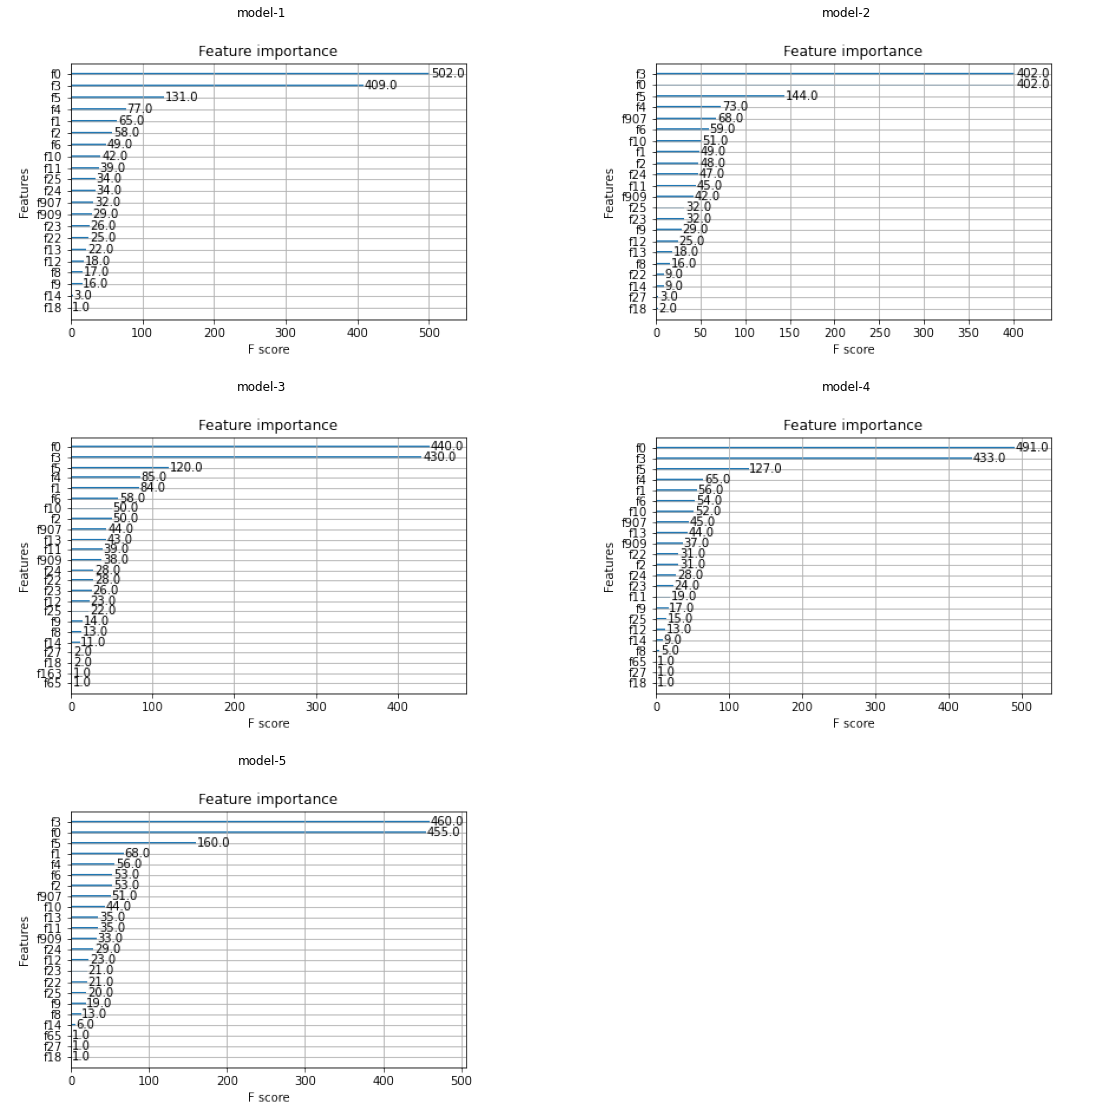

In [34]:
plot("feature_importance")

## ROC Curves

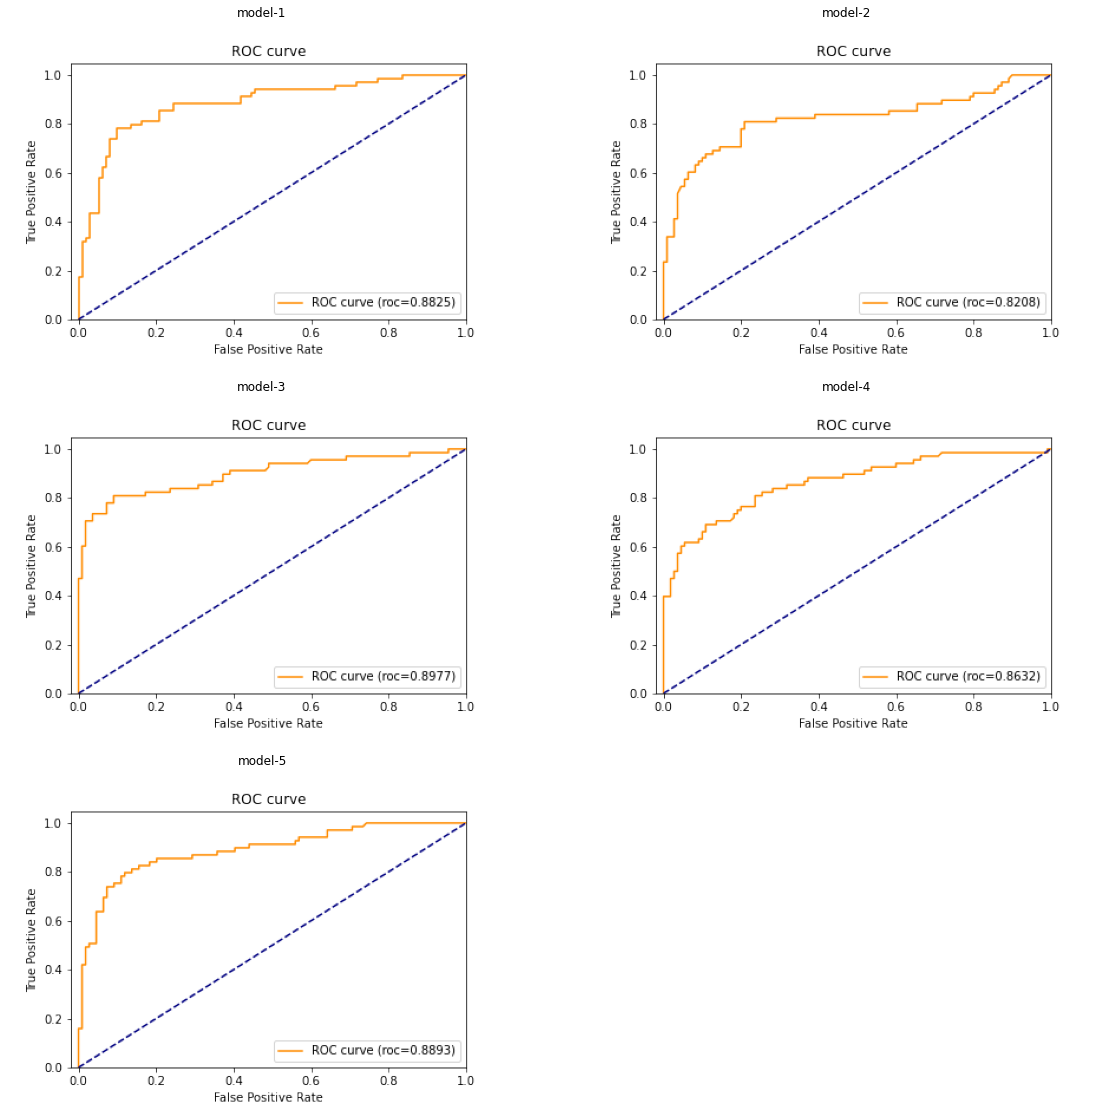

In [35]:
plot("roc")

## Loss Curves

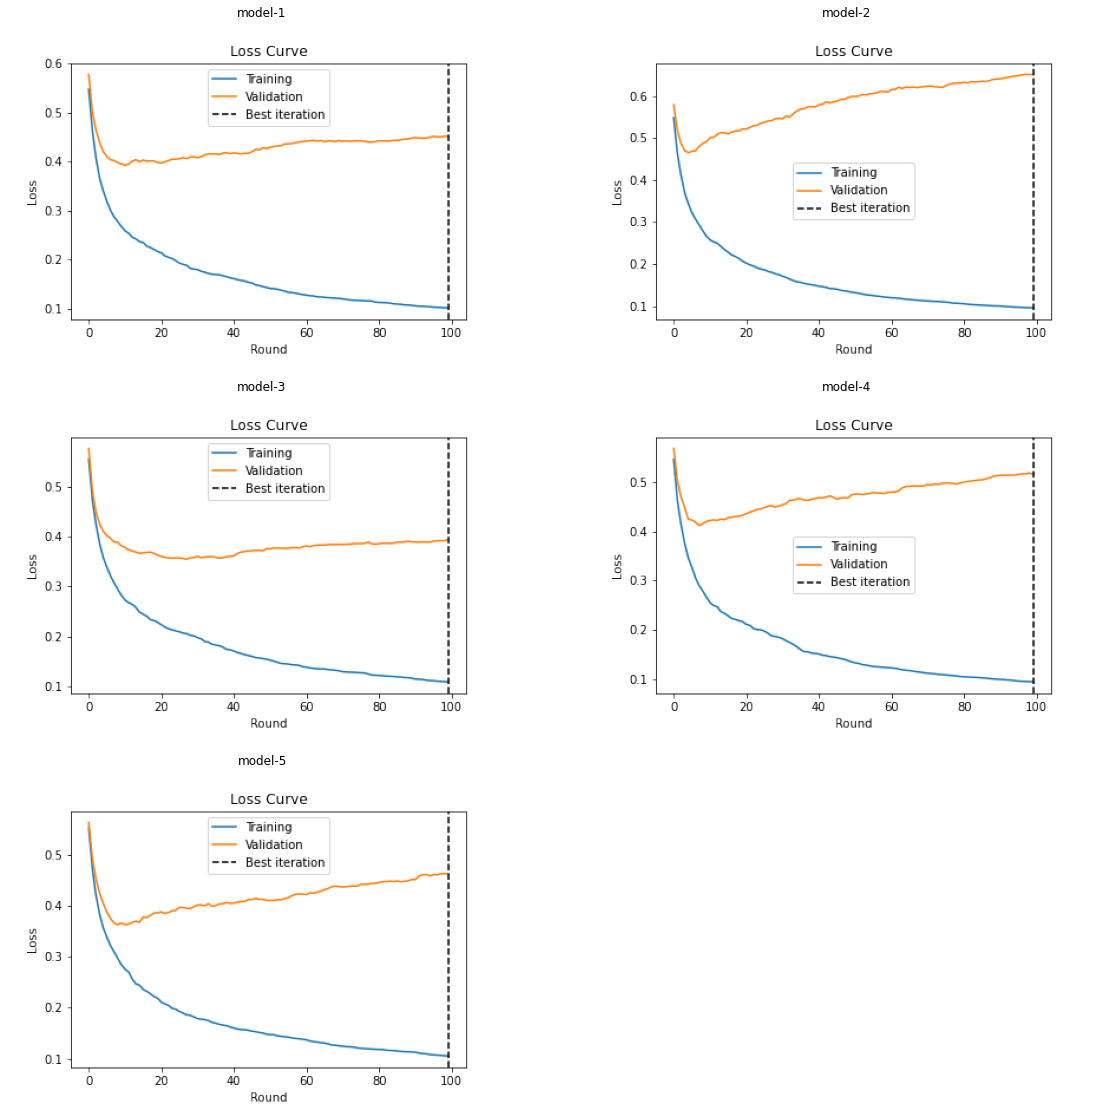

In [36]:
plot("loss_curves")

# Optuna-Tuned Model

Optuna is used to minimize the validation loss of the model.

In [37]:
MODEL_DIR = TUNED_MODELS_DIR

objective_ = functools.partial(objective, X=features, y=labels, pruner=True)

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.HyperbandPruner(),
    sampler=sampler,
)

# An extra trial is enqueued for Optuna to get a head start
study.enqueue_trial(
    {
        "max_depth": MAX_DEPTH,
        "alpha": ALPHA,
        "lr": LR,
        "n_estimators": N_ESTIMATORS,
    }
)

study.optimize(objective_, n_trials=100, gc_after_trial=True)

[I 2022-03-04 13:09:29,224] A new study created in memory with name: no-name-98dd6bad-2dce-468d-9c28-2e6516804383


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2022-03-04 13:09:31,107] Trial 0 finished with value: 0.441178560256958 and parameters: {'max_depth': 5, 'n_estimators': 100, 'alpha': 0.3, 'lambda': 1.8272261776066236, 'lr': 0.3, 'colsample_bytree': 0.960571445127933, 'colsample_bylevel': 0.7855951534491241, 'min_child_weight': 30.334265725654795, 'sampling_method': 'uniform', 'scale_pos_weight': 1.2323344486727978, 'early_stopping_rounds': 20}. Best is trial 0 with value: 0.441178560256958.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2022-03-04 13:09:32,616] Trial 1 finished with value: 0.48506027460098267 and parameters: {'max_depth': 7, 'n_estimators': 214, 'alpha': 0.10292247147901223, 'lambda': 4.763628595029447, 'lr': 0.46148589527579975, 'colsample_bytree': 0.36987128854262097, 'colsample_bylevel': 0.3454599737656805, 'min_child_weight': 9.986820982818257, 'sampling_method': 'gradient_based', 'scale_pos_weight': 2.727780074568463, 'early_stopping_rounds': 10}. Best is trial 0 with value: 0.441178560256958.


...

[I 2022-03-04 13:10:29,361] Trial 97 finished with value: 0.4376697540283203 and parameters: {'max_depth': 8, 'n_estimators': 19, 'alpha': 0.002896775584248134, 'lambda': 1.1594407388794092, 'lr': 0.3707814258867698, 'colsample_bytree': 0.9053291053554942, 'colsample_bylevel': 0.6791002772569579, 'min_child_weight': 1.3012714837394543, 'sampling_method': 'gradient_based', 'scale_pos_weight': 1.8266881405807476, 'early_stopping_rounds': 5}. Best is trial 73 with value: 0.422698974609375.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2022-03-04 13:10:31,278] Trial 98 finished with value: 0.44943055510520935 and parameters: {'max_depth': 6, 'n_estimators': 297, 'alpha': 1.0756115617058435, 'lambda': 1.8781694327320546, 'lr': 0.7874628365352702, 'colsample_bytree': 0.7006725603667168, 'colsample_bylevel': 0.7721272715887194, 'min_child_weight': 1.6213660005248713, 'sampling_method': 'uniform', 'scale_pos_weight': 1.9282212882311525, 'early_stopping_rounds': 15}. Best is trial 73 with value: 0.422698974609375.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2022-03-04 13:10:32,105] Trial 99 pruned. Trial was pruned at iteration 27.


# Train Final Model Using The Best Parameters

In [38]:
study.best_trial.params

{'max_depth': 4,
 'n_estimators': 21,
 'alpha': 2.1025019743570645,
 'lambda': 1.4963995538610317,
 'lr': 0.4718942367938231,
 'colsample_bytree': 0.9620262724135856,
 'colsample_bylevel': 0.7549300993895206,
 'min_child_weight': 8.607170892303422,
 'sampling_method': 'uniform',
 'scale_pos_weight': 1.0134533586741488,
 'early_stopping_rounds': 15}

In [39]:
best_trial = study.best_trial
print("\nTraining model with the best obtained hyperparameters:\n")
roc, loss, accuracies = train(X=features, y=labels, params=best_trial.params, save_model=True)
print(f"Optuna-tuned model: Average ROC={roc:.4f}; Average validation loss={loss:.4f}")
print(f"Accuracies: {accuracies}")


Training model with the best obtained hyperparameters:



  0%|          | 0/5 [00:00<?, ?it/s]

Optuna-tuned model: Average ROC=0.8793; Average validation loss=0.4227
Accuracies: [0.8435754189944135, 0.8314606741573034, 0.8370786516853933, 0.8202247191011236, 0.8146067415730337]


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

...

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

## Feature Importance

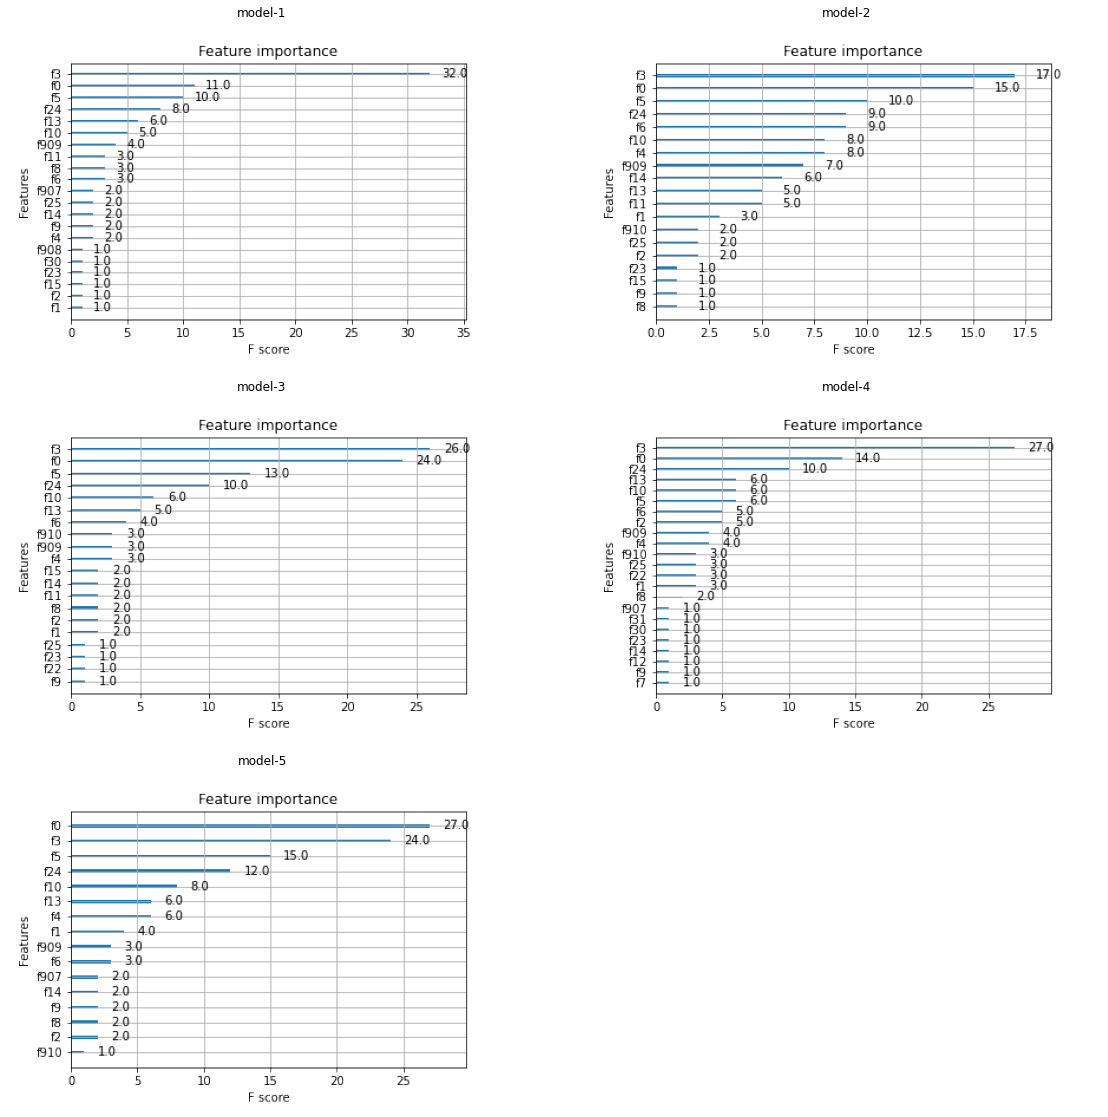

In [40]:
plot("feature_importance")

## ROC Curves

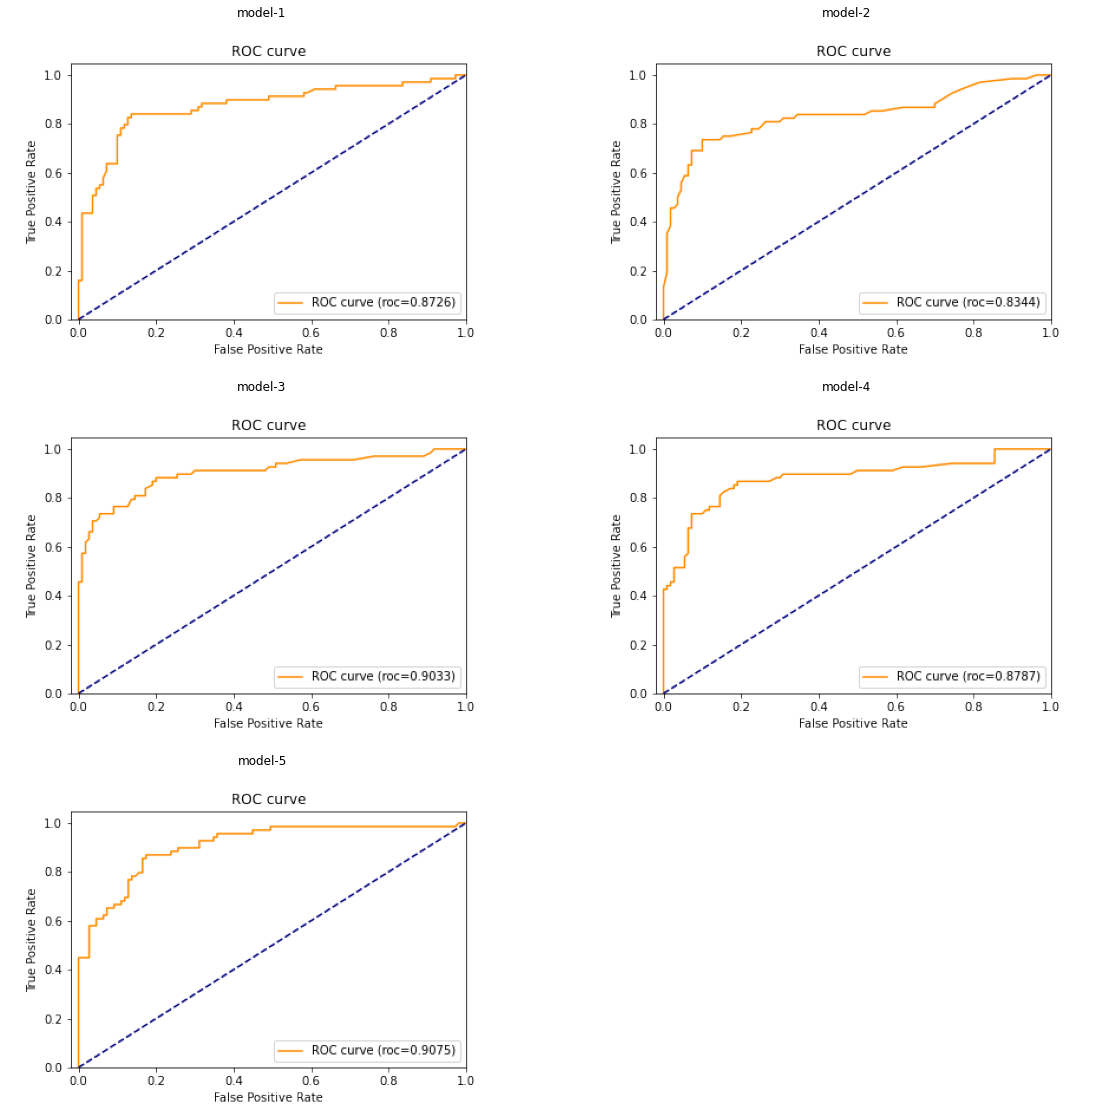

In [41]:
plot("roc")

## Loss Curves

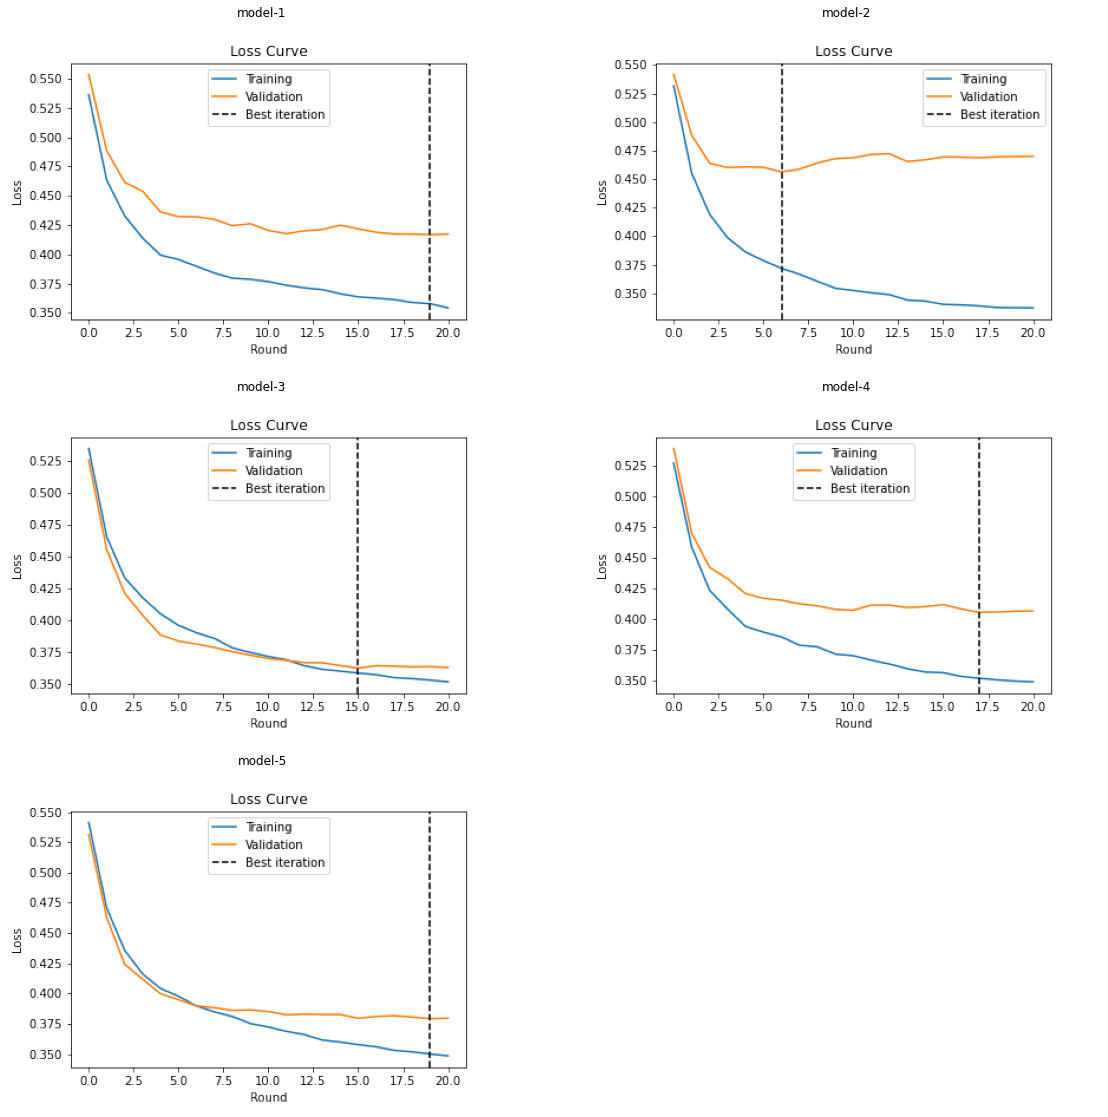

In [42]:
plot("loss_curves")

# Prediction

The predictions are made by a majority vote.

In [43]:
path = os.path.join(DATA_DIR, "test.csv")
test_df = pd.read_csv(path)
test_df.head()

,PassengerId,Age,SibSp,Parch,Fare,FamilySize,GroupSize,Sex_female,Sex_male,Pclass_1,...,Surname_de Messemaeker,Surname_de Mulder,Surname_de Pelsmaeker,Surname_del Carlo,Surname_van Billiard,Surname_van Melkebeke,missing_Age_False,missing_Age_True,missing_Cabin_False,missing_Cabin_True
0,892,34.5,0.0,0.0,7.8292,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,893,47.0,1.0,0.0,7.0000,2,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1
2,894,62.0,0.0,0.0,9.6875,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,895,27.0,0.0,0.0,8.6625,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1
4,896,22.0,1.0,1.0,12.2875,3,2,1,0,0,...,0,0,0,0,0,0,1,0,0,1


In [44]:
test_features = test_df.drop("PassengerId", axis=1).values

In [45]:
from scipy import stats
path = os.path.join(MODEL_DIR, f"model-3.json")
preds = []


for model_path in glob.glob(path):
    classifier = xgb.XGBClassifier(**get_model_params(best_trial.params))
    classifier.load_model(model_path)
    preds.append(classifier.predict(test_features))

preds = np.array(preds).T
preds = stats.mode(preds, axis=1).mode
preds = preds.astype(int)

In [46]:
# Make predictions
preds = classifier.predict(test_features, ntree_limit=classifier.best_ntree_limit)
test_df["Survived"] = preds.flat

In [47]:
submission_df = test_df[["PassengerId", "Survived"]]
submission_df["Survived"].value_counts()

0    254
1    164
Name: Survived, dtype: int64

In [48]:
submission_df.to_csv("submission.csv", index=False)